# EDP Week 3 — Spam Message Classifier

## Objective

To understand text preprocessing, convert text into numerical features using TF-IDF, train a Naive Bayes classification model, and evaluate its performance on SMS spam detection.

### Student Details

**Name:** Mohammed Abdul Raheem  
**Roll No:** 24951A1251  
**Batch:** 26  
**Project Track:** Stock Price Trend Predictor  
**EDP:** Week 3

In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Download the UCI SMS Spam Collection dataset

import requests
import zipfile
import io

zip_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"

# Download the zip file
response = requests.get(zip_url)

# Open the zip file from memory
with zipfile.ZipFile(io.BytesIO(response.content), 'r') as zf:
    # Read the specific file within the zip archive
    with zf.open('SMSSpamCollection') as unzipped_file:
        df = pd.read_csv(
            unzipped_file,
            sep="\t",
            header=None,
            names=["label", "message"]
        )

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
# Inspect the dataset

print("Dataset information:")
print(df.info())

print("\nClass distribution:")
print(df["label"].value_counts())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [7]:
# Convert labels into numerical values

df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [8]:
# Basic text preprocessing

df["message_clean"] = (
    df["message"]
    .str.lower()
    .str.replace(r"[^a-zA-Z\s]", "", regex=True)
    .str.strip()
)

df[["message", "message_clean", "label"]].head()

,message,message_clean,label
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,ham
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final...,spam
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,ham
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,ham


In [9]:
# Separate text features (X) and target labels (y)

X = df["message_clean"]
y = df["label_num"]

print("Number of messages:", len(X))
print("Number of labels:", len(y))

Number of messages: 5572
Number of labels: 5572


In [10]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [11]:
# Convert text into numerical features using TF-IDF

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (4457, 5000)
TF-IDF testing shape: (1115, 5000)


In [12]:
# Train a Naive Bayes classifier

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [13]:
# Make predictions on the test data

y_pred = model.predict(X_test_tfidf)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [14]:
# Evaluate the spam classifier

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

Accuracy: 0.9659

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



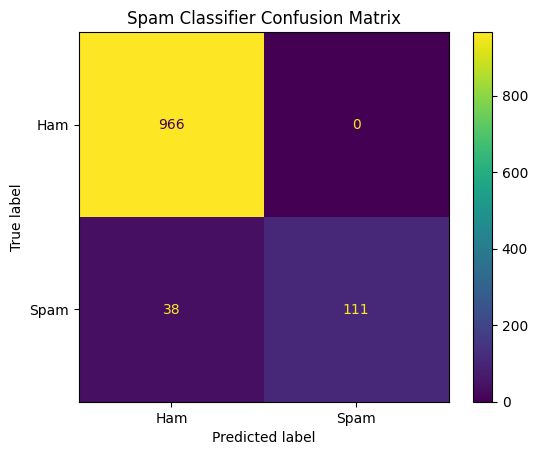

In [15]:
# Display the confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()

plt.title("Spam Classifier Confusion Matrix")
plt.show()

In [16]:
# Test the classifier with custom messages

test_messages = [
    "Congratulations! You have won a free prize. Call now to claim your reward!",
    "Hey, are we meeting at college tomorrow?",
    "URGENT! You have been selected for a cash reward. Click now!",
    "Can you send me the notes from today's class?"
]

test_tfidf = tfidf.transform(test_messages)

predictions = model.predict(test_tfidf)

for message, prediction in zip(test_messages, predictions):
    result = "SPAM" if prediction == 1 else "HAM"
    print(f"{result}: {message}")

SPAM: Congratulations! You have won a free prize. Call now to claim your reward!
HAM: Hey, are we meeting at college tomorrow?
SPAM: URGENT! You have been selected for a cash reward. Click now!
HAM: Can you send me the notes from today's class?


## Conclusion

In this project, a spam message classifier was developed using Python and Scikit-learn.

The SMS text data was cleaned through basic text preprocessing and converted into numerical features using TF-IDF. A Multinomial Naive Bayes classifier was then trained on the transformed training data.

The model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. The classifier was also tested on custom SMS messages to demonstrate its ability to distinguish between legitimate and spam messages.

This project provided practical understanding of text preprocessing, TF-IDF feature extraction, Naive Bayes classification, and evaluation of a text classification model.
